In [1]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Experiment_Pipeline\simple_fine_tuning\results\pso\pso_summary.csv

RESULTS_PATH = Path().resolve() / "pso_summary.csv"

df = pd.read_csv(RESULTS_PATH)
print("✅ CSV Loaded:", RESULTS_PATH)
print(df.head())
print(df.columns)

✅ CSV Loaded: C:\Users\57305\Downloads\FTZ_model_2.0\paper_results\fine_tuning\individual_algorithm_results\pso\pso_summary.csv
  algo  candidate_id  seed  best_final   auc_best  auc_best_norm  runtime_sec  \
0  pso           100  1001      438.50  43341.975     437.797727    69.500892   
1  pso           100   101      438.35  43378.350     438.165152    70.676682   
2  pso           100  1102      438.05  43359.225     437.971970    70.836998   
3  pso           100   202      438.20  43356.150     437.940909    63.943635   
4  pso           100   303      438.65  43367.025     438.050758    65.654261   

   evals_total  budget_triggered  stop_reason  cxpb  mutpb  mutation_rate  \
0           -1             False          NaN   NaN    NaN            NaN   
1           -1             False          NaN   NaN    NaN            NaN   
2           -1             False          NaN   NaN    NaN            NaN   
3           -1             False          NaN   NaN    NaN            NaN   


In [3]:
# ---------------------------------------------------
# 2) Sort + Inspect Best Runs (with full hyperparams)
# ---------------------------------------------------

df_sorted = df.sort_values(
    by=["best_final", "auc_best_norm"],
    ascending=[False, False],
    na_position="last"
)

TOP_N = 10 

cols_to_show = [
    
    "algo", "candidate_id", "seed",
    
    
    "best_final", "auc_best_norm", "runtime_sec",
    
    "c1", "c2", "w"
]

print(f"\n🏆 Top {TOP_N} PSO Runs (Metrics + Hyperparams):")
display(df_sorted[cols_to_show].head(TOP_N).style.background_gradient(cmap="viridis"))

# Best explicit
best_row = df_sorted.iloc[0]
print("\n✅ BEST RUN SELECTED:")
display(best_row[cols_to_show])



🏆 Top 10 PSO Runs (Metrics + Hyperparams):


,algo,candidate_id,seed,best_final,auc_best_norm,runtime_sec,c1,c2,w
691,pso,66,808,438.650000,438.532576,94.561391,1.424308,2.196502,0.968923
684,pso,66,1102,438.650000,438.509848,107.426618,1.424308,2.196502,0.968923
783,pso,74,1102,438.650000,438.496212,88.584665,1.205963,2.200000,0.944692
790,pso,74,808,438.650000,438.491667,88.004696,1.205963,2.200000,0.944692
339,pso,37,808,438.650000,438.482576,105.126755,1.484517,1.757067,0.945514
332,pso,37,1102,438.650000,438.468939,100.989576,1.484517,1.757067,0.945514
738,pso,70,101,438.650000,438.463636,89.494220,2.200000,1.295792,0.938489
782,pso,74,101,438.650000,438.463636,87.266055,1.205963,2.200000,0.944692
686,pso,66,303,438.650000,438.455303,88.167526,1.424308,2.196502,0.968923
331,pso,37,101,438.650000,438.454545,94.317617,1.484517,1.757067,0.945514



✅ BEST RUN SELECTED:


algo                    pso
candidate_id             66
seed                    808
best_final           438.65
auc_best_norm    438.532576
runtime_sec       94.561391
c1                 1.424308
c2                 2.196502
w                  0.968923
Name: 691, dtype: object

In [4]:
# =======================================================
# Aggregation by Candidate (11 seeds per candidate)
# =======================================================

agg = df.groupby("candidate_id").agg({
    "best_final": ["mean", "max"],
    "auc_best_norm": ["mean", "max"],
    "runtime_sec": "mean",
    "evals_total": "mean",
    "seed": "count",
    "c1": "mean",
    "c2": "mean",
    "w": "mean" # sanity check: should be 11
})

# Flatten MultiIndex columns
agg.columns = [
    f"{m}_{s}" if s != "" else m
    for m, s in agg.columns.map(lambda x: (x[0], "" if x[1] == "" else x[1]))
]

# Order by best performance + best stability
agg_sorted = agg.sort_values(
    by=["best_final_max", "auc_best_norm_mean"],
    ascending=[False, False]
)

print("✅ Aggregated results by candidate:")
display(agg_sorted.head(10))

✅ Aggregated results by candidate:


,best_final_mean,best_final_max,auc_best_norm_mean,auc_best_norm_max,runtime_sec_mean,evals_total_mean,seed_count,c1_mean,c2_mean,w_mean
candidate_id,,,,,,,,,,
66,438.650000,438.65,438.423485,438.532576,98.291812,-1.0,11,1.424308,2.196502,0.968923
74,438.650000,438.65,438.413843,438.496212,86.921496,-1.0,11,1.205963,2.200000,0.944692
37,438.650000,438.65,438.376515,438.482576,97.224250,-1.0,11,1.484517,1.757067,0.945514
70,438.650000,438.65,438.374311,438.463636,94.543056,-1.0,11,2.200000,1.295792,0.938489
93,438.650000,438.65,438.366873,438.450758,87.841828,-1.0,11,0.890394,1.752640,0.966471
69,438.650000,438.65,438.363017,438.430303,91.307141,-1.0,11,1.174311,1.857215,0.924871
72,438.650000,438.65,438.346625,438.418939,96.706662,-1.0,11,0.800000,1.396712,0.974955
30,438.650000,438.65,438.343182,438.434848,95.493419,-1.0,11,1.748380,1.120130,0.952250
81,438.650000,438.65,438.338636,438.407576,83.916467,-1.0,11,2.054358,1.422471,0.905360


In [5]:
import os
import json
import pandas as pd


results_dir = Path().resolve() / "runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),

            
            "c1": h.get("c1"),
            "c2": h.get("c2"),
            "w": h.get("w"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,c1,c2,w,popsize,generations,L_used,runtime_sec_meta
0,1,101,pso,438.65,43398.300,438.366667,77.908736,-1,False,2.10,0.004810,1.527813,0.922512,0.745984,22,100,None,77.908736
1,1,202,pso,438.20,43370.550,438.086364,86.300165,-1,False,2.10,0.004815,1.527813,0.922512,0.745984,22,100,None,86.300165
2,1,303,pso,438.65,43383.975,438.221970,72.346507,-1,False,2.55,0.005847,1.527813,0.922512,0.745984,22,100,None,72.346507
3,1,404,pso,438.35,43369.500,438.075758,70.929213,-1,False,2.10,0.004814,1.527813,0.922512,0.745984,22,100,None,70.929213
4,1,505,pso,438.65,43379.700,438.178788,77.409258,-1,False,2.70,0.006193,1.527813,0.922512,0.745984,22,100,None,77.409258


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 608.484, p = 2.772e-74


In [7]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
66,1043.545455,78.013926,11,493.045455
74,1031.500000,95.758028,11,481.000000
70,979.000000,96.859434,11,428.500000
37,970.181818,98.065099,11,419.681818
93,963.681818,116.361564,11,413.181818
69,961.454545,92.247074,11,410.954545
72,931.045455,109.935312,11,380.545455
30,924.090909,108.719322,11,373.590909
81,916.818182,100.151204,11,366.318182


C:\Users\57305\AppData\Local\Temp\ipykernel_26036\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


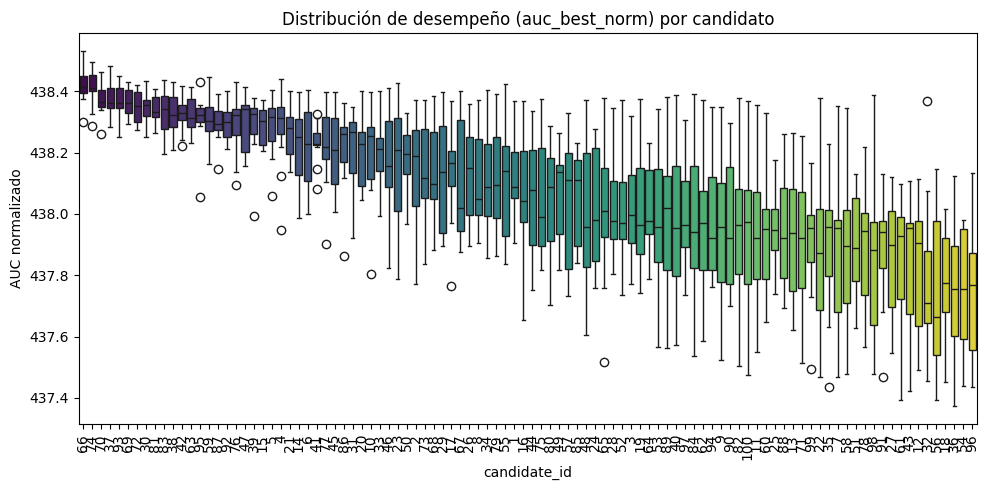

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,63 > 96,11,11,121.0,0.000041,0.200817,False
1,63 > 99,11,11,121.0,0.000041,0.200817,False
2,63 > 78,11,11,121.0,0.000041,0.200817,False
3,63 > 91,11,11,121.0,0.000041,0.200817,False
4,37 > 49,11,11,121.0,0.000041,0.201751,False
5,92 > 99,11,11,121.0,0.000041,0.201751,False
6,92 > 96,11,11,121.0,0.000041,0.201751,False
7,93 > 99,11,11,121.0,0.000041,0.201751,False
8,37 > 96,11,11,121.0,0.000041,0.201751,False
9,20 > 54,11,11,121.0,0.000041,0.201751,False


In [10]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [11]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,63 > 96,11,11,121.0,0.000041,0.200817,False
1,63 > 99,11,11,121.0,0.000041,0.200817,False
2,63 > 78,11,11,121.0,0.000041,0.200817,False
3,63 > 91,11,11,121.0,0.000041,0.200817,False
4,37 > 49,11,11,121.0,0.000041,0.201751,False
...,...,...,...,...,...,...,...
4945,43 > 63,11,11,0.0,0.999969,4949.847605,False
4946,54 > 63,11,11,0.0,0.999969,4949.847605,False
4947,36 > 63,11,11,0.0,0.999969,4949.847605,False
4948,35 > 63,11,11,0.0,0.999969,4949.847605,False


In [12]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


KeyboardInterrupt: 

In [ ]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [ ]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
...,...,...,...
96,0,0,0
97,0,0,0
98,0,0,0
99,0,0,0


# Candidatos

In [ ]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 66            438.423485  0.064126  438.388450
 74            438.413843  0.064224  438.378755
 70            438.374311  0.055263  438.344119
 37            438.376515  0.065378  438.340797
 69            438.363017  0.044810  438.338535
 93            438.366873  0.064575  438.331594
 72            438.346625  0.054790  438.316691
 30            438.343182  0.055103  438.313077
 81            438.338636  0.048498  438.312140
 42            438.325689  0.057880  438.294066,
 [66, 74, 70, 37, 69, 93, 72, 30, 81, 42])

In [ ]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,66,30,11,66.0,0.000488,0.021973,True,0.021973,True
1,74,72,11,66.0,0.000488,0.021973,True,0.021973,True
2,74,37,11,66.0,0.000488,0.021973,True,0.021973,True
3,74,30,11,66.0,0.000488,0.021973,True,0.021973,True
4,74,93,11,66.0,0.000488,0.021973,True,0.021973,True
5,66,42,11,66.0,0.000488,0.021973,True,0.021973,True
6,74,42,11,66.0,0.000488,0.021973,True,0.021973,True
7,66,72,11,65.0,0.000977,0.037109,True,0.043945,True
8,66,93,11,64.0,0.001465,0.054199,False,0.065918,False
9,66,81,11,64.0,0.001465,0.054199,False,0.065918,False


In [ ]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
74,5,0,5,1.0
66,3,0,3,1.0
69,0,0,0,0.0
70,0,0,0,0.0
81,0,0,0,0.0
37,0,1,-1,0.0
93,0,1,-1,0.0
30,0,2,-2,0.0
42,0,2,-2,0.0
72,0,2,-2,0.0


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# --- Cara-a-cara 74 vs 66, pareado por seed ---
metric = "auc_best_norm"
pair = (74, 66)

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)
xy = pivot[list(pair)].dropna()
d = xy[pair[0]] - xy[pair[1]]

stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")

print(f"Wilcoxon paired (one-sided): {pair[0]} > {pair[1]}")
print(f"n={len(d)}, stat={stat:.3f}, p={p:.6g}")
print(f"mean diff={d.mean():.6f}, median diff={d.median():.6f}")

# --- Tamaño de efecto: Cliff's delta ---
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in y for yi in x)  # equivalente
    n = len(x) * len(y)
    return (gt - lt) / n

delta = cliffs_delta(xy[pair[0]].values, xy[pair[1]].values)
print(f"Cliff's delta = {delta:.3f}  (≈0.147 pequeño, 0.33 mediano, 0.474 grande)")

# --- Desempate por LCB95 si no hay significancia ---
g = df_finetuning[df_finetuning["candidate_id"].isin(pair)].groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)
tcrit = 1.812  # one-sided 95%, df=10
lcb95 = mean - tcrit * se

print("\nLCB95:")
print(pd.DataFrame({"mean": mean, "std": std, "n": n, "se": se, "lcb95": lcb95}).loc[list(pair)])

# --- (Opcional) criterio aún más robusto: percentil 10 por candidato ---
p10 = df_finetuning[df_finetuning["candidate_id"].isin(pair)].groupby("candidate_id")[metric].quantile(0.10)
print("\nP10 (percentil 10):")
print(p10)


Wilcoxon paired (one-sided): 74 > 66
n=11, stat=25.000, p=0.753906
mean diff=-0.009642, median diff=-0.004545
Cliff's delta = 0.000  (≈0.147 pequeño, 0.33 mediano, 0.474 grande)

LCB95:
                    mean       std   n        se       lcb95
candidate_id                                                
74            438.413843  0.064224  11  0.019364  438.378755
66            438.423485  0.064126  11  0.019335  438.388450

P10 (percentil 10):
candidate_id
66    438.374242
74    438.325000
Name: auc_best_norm, dtype: float64


In [ ]:
# Empate estadístico → desempatar por robustez y cola baja
pair = [66, 74]
g = df_finetuning[df_finetuning["candidate_id"].isin(pair)].groupby("candidate_id")["auc_best_norm"]

mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / (n**0.5)
tcrit = 1.812  # one-sided 95%, df=10

lcb95 = mean - tcrit * se
p10 = g.quantile(0.10)

summary = (
    pd.DataFrame({"mean": mean, "std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10})
    .sort_values(["lcb95", "p10", "mean"], ascending=[False, False, False])
)
winner = summary.index[0]
summary, int(winner)


(                    mean       std   n        se       lcb95         p10
 candidate_id                                                            
 66            438.423485  0.064126  11  0.019335  438.388450  438.374242
 74            438.413843  0.064224  11  0.019364  438.378755  438.325000,
 66)

C:\Users\57305\AppData\Local\Temp\ipykernel_33324\455360736.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",


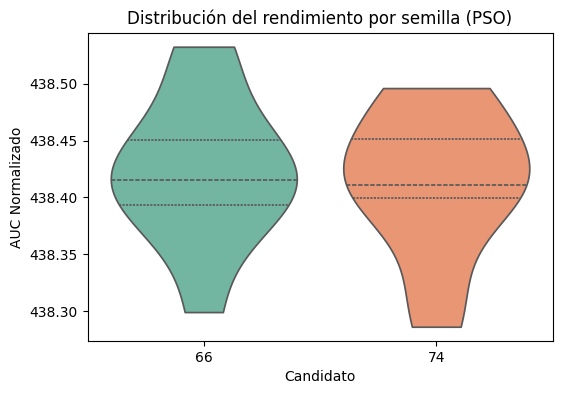

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pair = [66, 74]
subset = df_finetuning[df_finetuning["candidate_id"].isin(pair)]

plt.figure(figsize=(6,4))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0, palette="Set2")
plt.title("Distribución del rendimiento por semilla (PSO)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.show()


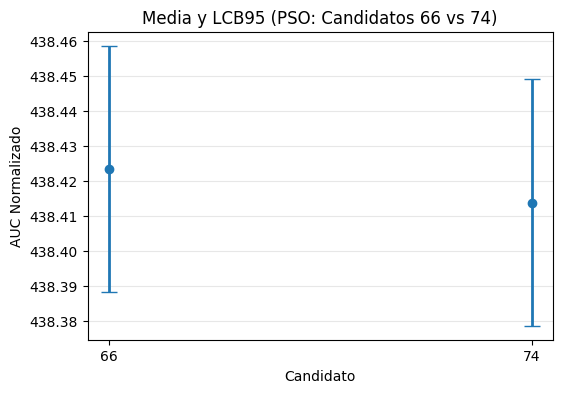

In [ ]:
df_plot = summary.copy()

plt.figure(figsize=(6,4))
plt.errorbar(
    x=df_plot.index.astype(str),
    y=df_plot["mean"],
    yerr=df_plot["mean"] - df_plot["lcb95"],
    fmt='o', capsize=6, linewidth=2
)
plt.title("Media y LCB95 (PSO: Candidatos 66 vs 74)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.show()


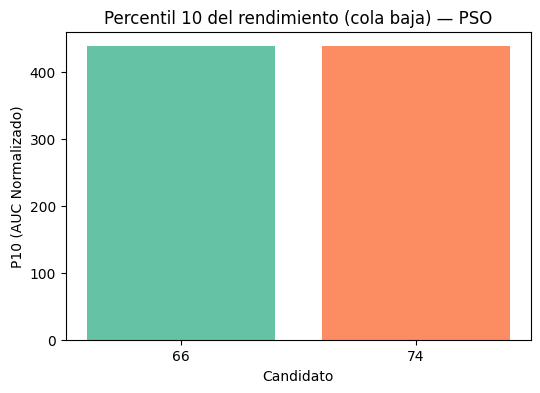

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(df_plot.index.astype(str), df_plot["p10"], color=["#66c2a5", "#fc8d62"])
plt.title("Percentil 10 del rendimiento (cola baja) — PSO")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.show()
